In [2]:
# All imports needed
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt

In [3]:
# Getting Data Ready
path = "sms+spam+collection/SMSSpamCollection"

df = pd.read_csv(path, sep=r"\t", header=None, engine="python")
df = df.rename({0:"Class", 1:"SMS"}, axis=1)

In [4]:
# Function to clean up messages

def clean_str(txt):
    txt = txt.lower()
    # remove leading and trailing whitespace
    txt = txt.strip()
    # removes extra spaces in between words
    txt = re.sub(r'\s+', ' ', txt)

    return txt

# EDA

In [5]:
# Split
spam = df[df['Class'] == 'spam']
ham = df[df['Class'] == 'ham']


In [6]:
# Check the number of spam and ham messages we have to work with
print(f'Spam Count: {spam.shape[0]}\nHam Count: {ham.shape[0]}')

Spam Count: 747
Ham Count: 4827


Very skewed ratio between spam and ham that we have to work with. This will need to be something to consider when creating our model.
* Using metrics like precision, accuracy, and recall might not be best since there is very little spam data. 
* If we were to choose one, we should maybe prioritize false negatives (is spam but marked as non spam) since it would be better to let a spam email pass as opposed to marking an important message as spam and blocking it from going through, so we should use recall

In [15]:
# Check to see if there is an average difference in punctuation/special characters with spam and ham messages

def punc_count(sentence):
    punctuations = re.findall(r'[^A-Za-z0-9\s]+', sentence)
    return punctuations

In [ ]:
ham_punc_counts = ham['SMS'].apply(len(punc_count))
spam_punc_counts = spam['SMS'].apply(len(punc_count))

In [9]:
print(f'Ham Punctuation Average: {ham_punc_counts.mean():.2f}\nSpam Punctuation Average: {spam_punc_counts.mean():.2f}')

Ham Punctuation Average: 2.98
Spam Punctuation Average: 5.87


In [27]:
all_punc = []

for sent in list(df['SMS']):
    all_punc += punc_count(sent)
print(len(set(all_punc)))
print('-------------')

all_punc = pd.Series(all_punc)

all_punc.value_counts()


248
-------------


.            5837
,            1947
'            1796
?            1431
!            1121
             ... 
:):)            1
;>              1
...;-)          1
...!鈥┾??〨       1
+).             1
Name: count, Length: 248, dtype: int64

Seems like spam messages tend to have more punctuations/special characters as opposed to ham messages. We can maybe factor this into our model to make a better prediction as to whether or not a message is spam or ham. 

There also doesn't seem to be many region specific symbols, like the pound symbol for example, that are used. We can probably remove or interpret this symbol as a universal currency symbol so as to generalize our model to different regions with different currency. 

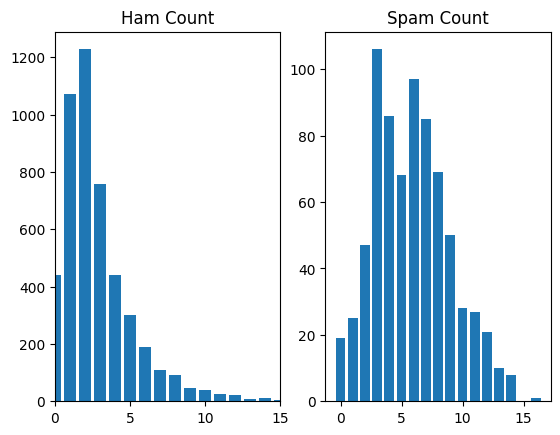

In [11]:
sorted_count_ham = ham_punc_counts.value_counts().sort_index()
sorted_count_spam = spam_punc_counts.value_counts().sort_index()

x_ham = sorted_count_ham.index
y_ham = sorted_count_ham.values

x_spam = sorted_count_spam.index
y_spam = sorted_count_spam.values

fig, axs = plt.subplots(nrows=1, ncols=2)

axs[0].bar(x_ham, y_ham)
axs[1].bar(x_spam, y_spam)

axs[0].set_title('Ham Count')
axs[1].set_title('Spam Count')

axs[0].set_xlim(0, 15)

plt.show()

As we could see, the non spam punctuation counter is right skewed. And the spam seems to be normally distributed around the 5-6 mark